In [1]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline
import matplotlib.pyplot as plt

import random

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#si queremos mejorar este codigo deberiamos de usar el siguiente para que se use cuda siempre y cuando existan esos nuvles y si no permanecer en cpu
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f'Dispositivo en uso: {device}')
#print(f'Versión de PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
df_emnist = pd.read_csv("dt_exi/data.csv")

print("Forma del dataset:", df_emnist.shape)


Forma del dataset: (92000, 1025)


In [4]:
datos_modelo_emnist = df_emnist.copy()

print("Dataset original:", df_emnist.shape)
print("Copia para el modelo:", datos_modelo_emnist.shape)

Dataset original: (92000, 1025)
Copia para el modelo: (92000, 1025)


In [5]:
from sklearn.preprocessing import LabelEncoder

X_emnist = datos_modelo_emnist.drop(columns=["character"])
y_text_emnist = datos_modelo_emnist["character"]


print(y_text_emnist.value_counts())

le = LabelEncoder()
y_emnist = le.fit_transform(y_text_emnist)   

print("Clases codificadas:", le.classes_[:5], "...")

character
character_01_ka              2000
character_02_kha             2000
character_03_ga              2000
character_04_gha             2000
character_05_kna             2000
character_06_cha             2000
character_07_chha            2000
character_08_ja              2000
character_09_jha             2000
character_10_yna             2000
character_11_taamatar        2000
character_12_thaa            2000
character_13_daa             2000
character_14_dhaa            2000
character_15_adna            2000
character_16_tabala          2000
character_17_tha             2000
character_18_da              2000
character_19_dha             2000
character_20_na              2000
character_21_pa              2000
character_22_pha             2000
character_23_ba              2000
character_24_bha             2000
character_25_ma              2000
character_26_yaw             2000
character_27_ra              2000
character_28_la              2000
character_29_waw             2000
char

In [6]:
X_emnist = X_emnist.to_numpy()
#y_emnist = y_emnist.to_numpy()

In [7]:
from sklearn.model_selection import train_test_split

X_train_emnist, X_test_emnist, y_train_emnist, y_test_emnist = train_test_split(
    X_emnist, y_emnist,
    test_size=0.20,
    random_state=42,
    stratify=y_emnist
)


X_train_emnist, X_val_emnist, y_train_emnist, y_val_emnist = train_test_split(
    X_train_emnist, y_train_emnist,
    test_size=0.125,
    random_state=42,
    stratify=y_train_emnist
)

print("X_train:", X_train_emnist.shape)
print("X_val:", X_val_emnist.shape)
print("X_test:", X_test_emnist.shape)
print("y_train:", y_train_emnist.shape)
print("y_val:", y_val_emnist.shape)
print("y_test:", y_test_emnist.shape)

X_train: (64400, 1024)
X_val: (9200, 1024)
X_test: (18400, 1024)
y_train: (64400,)
y_val: (9200,)
y_test: (18400,)


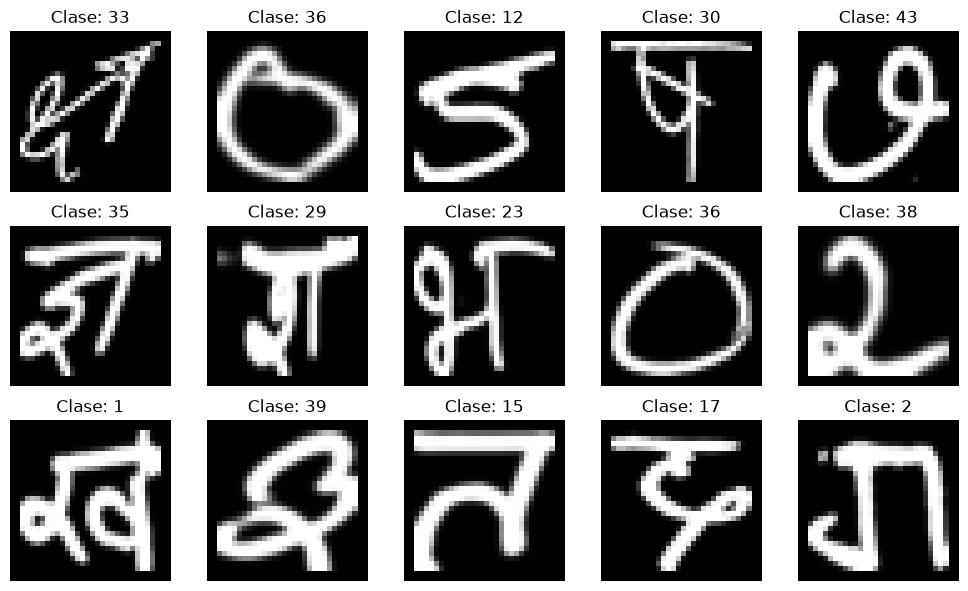

In [8]:
r, c = 3, 5

fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_train_emnist) - 1)

        img = X_train_emnist[ix]

        plt.imshow(
            img.reshape(32, 32),
            cmap="gray"
        )

        plt.axis("off")
        plt.title(f"Clase: {y_train_emnist[ix]}")

plt.tight_layout()
plt.show()

In [9]:

X_train_emnist = X_train_emnist / 255.0
X_test_emnist = X_test_emnist / 255.0
x_val_emnist = X_val_emnist / 255.0


y_train_emnist = y_train_emnist.astype(np.int64)
y_test_emnist = y_test_emnist.astype(np.int64)
y_val_emnist = y_val_emnist.astype(np.int64)

In [10]:
import torch

X_train_emnist_t = torch.tensor(
    X_train_emnist,
    dtype=torch.float32
).cuda()

X_test_emnist_t = torch.tensor(
    X_test_emnist,
    dtype=torch.float32
).cuda()

y_train_emnist_t = torch.tensor(
    y_train_emnist,
    dtype=torch.long
).cuda()

y_test_emnist_t = torch.tensor(
    y_test_emnist,
    dtype=torch.long
).cuda()

x_val_emnist_t = torch.tensor(
    x_val_emnist,
    dtype=torch.float32
).cuda()

y_val_emnist_t = torch.tensor(
    y_val_emnist,
    dtype=torch.long
).cuda()


In [11]:
D_in, H1, H2, D_out = 1024, 200, 150, 46
model_emnist = torch.nn.Sequential(
torch.nn.Linear(D_in, H1),
torch.nn.ReLU(),
torch.nn.Dropout(0.2),
torch.nn.Linear(H1, H2),
torch.nn.ReLU(),
torch.nn.Dropout(0.2),
torch.nn.Linear(H2, D_out),
).cuda()

criterion_emnist = torch.nn.CrossEntropyLoss()


optimizer_emnist = torch.optim.Adam(model_emnist.parameters(), lr=0.008)

epochs = 2000
log_each = 10

l_emnist = []
val_l_emnist = []         

best_val_loss = float("inf")
patience = 500                 
step = 0                       

model_emnist.train()

for e in range(1, epochs + 1):

    model_emnist.train()             

    
    y_pred_emnist = model_emnist(X_train_emnist_t)

   
    loss_emnist = criterion_emnist(
        y_pred_emnist,
        y_train_emnist_t
    )

    l_emnist.append(loss_emnist.item())

    
    optimizer_emnist.zero_grad()

    
    loss_emnist.backward()


    optimizer_emnist.step()

   
    model_emnist.eval()
    with torch.no_grad():
        val_logits_emnist = model_emnist(x_val_emnist_t)
        val_loss_emnist = criterion_emnist(
            val_logits_emnist,
            y_val_emnist_t
        )
    val_l_emnist.append(val_loss_emnist.item())

    if val_loss_emnist.item() < best_val_loss:
        best_val_loss = val_loss_emnist.item()
        torch.save(model_emnist.state_dict(), "ckpt_emnist.pt")
        step = 0
    else:
        step += 1

    if step > patience:
        print(f"Early stopping en epoch {e} (sin mejora en {patience} epochs)")
        break
    

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {loss_emnist.item():.5f} "
            f"Val_loss {val_loss_emnist.item():.5f}" 
        )

model_emnist.load_state_dict(torch.load("ckpt_emnist.pt"))  

Epoch 10/2000 Loss 2.28368 Val_loss 2.00230
Epoch 20/2000 Loss 1.47934 Val_loss 1.27324
Epoch 30/2000 Loss 1.11926 Val_loss 0.94006
Epoch 40/2000 Loss 0.88959 Val_loss 0.71947
Epoch 50/2000 Loss 0.74166 Val_loss 0.58159
Epoch 60/2000 Loss 0.63724 Val_loss 0.49240
Epoch 70/2000 Loss 0.56438 Val_loss 0.43671
Epoch 80/2000 Loss 0.50813 Val_loss 0.39628
Epoch 90/2000 Loss 0.45729 Val_loss 0.36423
Epoch 100/2000 Loss 0.42220 Val_loss 0.33884
Epoch 110/2000 Loss 0.39215 Val_loss 0.31932
Epoch 120/2000 Loss 0.36610 Val_loss 0.30275
Epoch 130/2000 Loss 0.34655 Val_loss 0.29030
Epoch 140/2000 Loss 0.32740 Val_loss 0.27931
Epoch 150/2000 Loss 0.30766 Val_loss 0.26870
Epoch 160/2000 Loss 0.28858 Val_loss 0.26173
Epoch 170/2000 Loss 0.27333 Val_loss 0.25626
Epoch 180/2000 Loss 0.26070 Val_loss 0.24960
Epoch 190/2000 Loss 0.24930 Val_loss 0.24691
Epoch 200/2000 Loss 0.23781 Val_loss 0.24298
Epoch 210/2000 Loss 0.22919 Val_loss 0.23837
Epoch 220/2000 Loss 0.22122 Val_loss 0.23363
Epoch 230/2000 Loss

<All keys matched successfully>

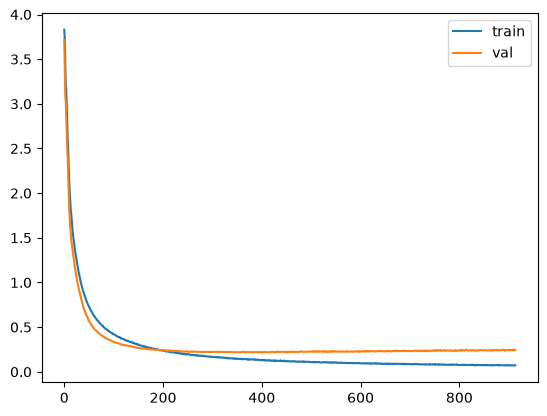

In [12]:
plt.plot(l_emnist, label="train")
plt.plot(val_l_emnist, label="val")
plt.legend()
plt.show()

In [13]:
from sklearn.metrics import accuracy_score

def evaluate_emnist(x):

    model_emnist.eval()

    logits = model_emnist(x)

    probabilidades = torch.softmax(logits, dim=1)

    predicciones = torch.argmax(
        probabilidades,
        dim=1
    )

    return predicciones

In [14]:
y_pred_emnist = evaluate_emnist(
    X_test_emnist_t
)

accuracy_emnist = accuracy_score(
    y_test_emnist_t.cpu().numpy(),
    y_pred_emnist.cpu().numpy()
)

print(f"Accuracy: {accuracy_emnist * 100:.2f}%")

Accuracy: 94.03%


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_21112\2691392283.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:255.)
  torch.tensor(


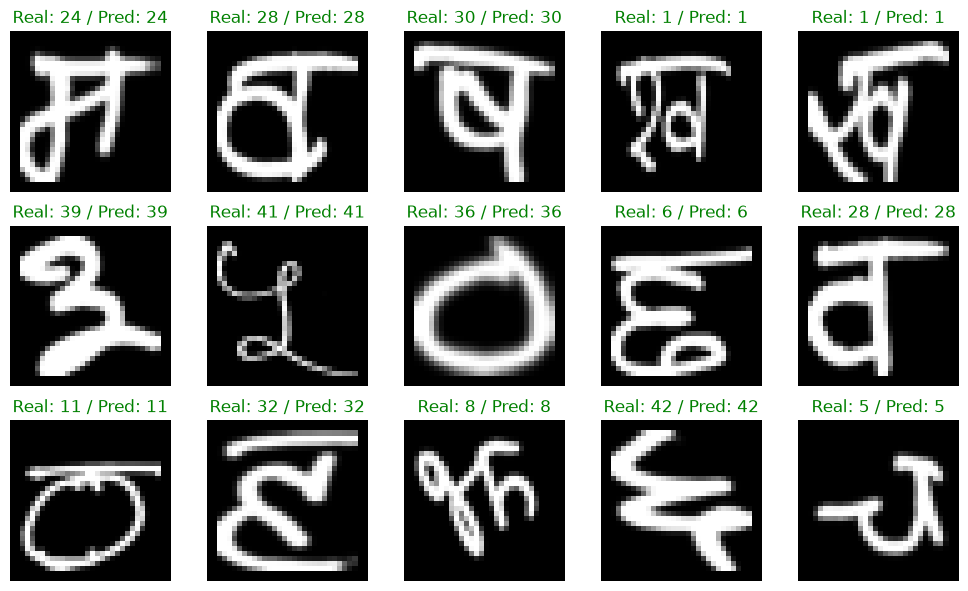

In [15]:
r, c = 3, 5

fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_test_emnist) - 1)

        img = X_test_emnist[ix]

        y_real = y_test_emnist[ix]

        y_pred = evaluate_emnist(
            torch.tensor(
                [img],
                dtype=torch.float32,
                device="cuda"
            )
        )[0].item()

        plt.imshow(
            img.reshape(32, 32),
            cmap="gray"
        )

        plt.axis("off")

        plt.title(
            f"Real: {y_real} / Pred: {y_pred}",
            color="green" if y_real == y_pred else "red"
        )

plt.tight_layout()
plt.show()

# APLICAMOS LAS NUEVAS METRICAS

#### matriz de confucion

In [16]:
from sklearn.metrics import confusion_matrix

cm_emnist = confusion_matrix(
    y_test_emnist_t.cpu().numpy(),
    y_pred_emnist.cpu().numpy()
)

print(cm_emnist)

[[388   0   0 ...   0   0   1]
 [  0 373   0 ...   0   0   0]
 [  0   2 378 ...   0   0   0]
 ...
 [  0   0   0 ... 395   0   0]
 [  0   0   0 ...   0 396   0]
 [  0   0   0 ...   1   0 393]]


#### presision y recall

In [17]:
from sklearn.metrics import precision_score, recall_score

precision_emnist = precision_score(
    y_test_emnist_t.cpu().numpy(),
    y_pred_emnist.cpu().numpy(),
    average="macro"
)
recall_emnist = recall_score(
    y_test_emnist_t.cpu().numpy(),
    y_pred_emnist.cpu().numpy(),
    average="macro"
)

precision_emnist, recall_emnist

(0.9404655801221665, 0.9403260869565216)

#### F1-score

In [18]:
from sklearn.metrics import f1_score

f1_emnist = f1_score(
    y_test_emnist_t.cpu().numpy(),
    y_pred_emnist.cpu().numpy(),
    average="macro"
)

f1_emnist

0.9402428060333967

#### curva ROCK/AUC

In [19]:
from sklearn.metrics import roc_auc_score

model_emnist.eval()
with torch.no_grad():
    logits_emnist = model_emnist(X_test_emnist_t)
    probabilidades_emnist = torch.softmax(logits_emnist, dim=1)

auc_emnist = roc_auc_score(
    y_test_emnist_t.cpu().numpy(),
    probabilidades_emnist.cpu().numpy(),
    multi_class="ovr",
    average="macro"
)

auc_emnist

0.9991400135869565

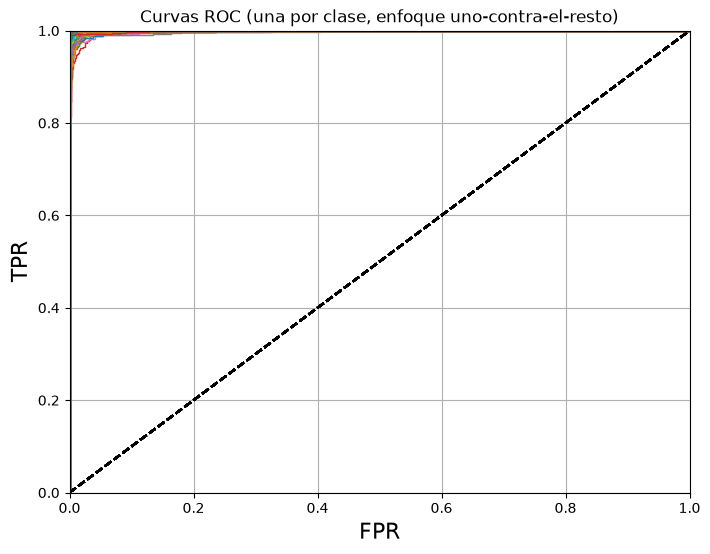

In [20]:
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np


y_test_bin_emnist = label_binarize(
    y_test_emnist_t.cpu().numpy(),
    classes=np.arange(D_out)
)


def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=1, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('FPR', fontsize=16)
    plt.ylabel('TPR', fontsize=16)
    plt.grid(True)

plt.figure(figsize=(8, 6))


for clase in range(D_out):
    fpr, tpr, _ = roc_curve(
        y_test_bin_emnist[:, clase],
        probabilidades_emnist.cpu().numpy()[:, clase]
    )
    plot_roc_curve(fpr, tpr)

plt.title("Curvas ROC (una por clase, enfoque uno-contra-el-resto)")
plt.show()